In [19]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
import seaborn as sns




In [20]:
df=pd.read_csv(r"C:\Users\muham\OneDrive\Desktop\pandas_full\students.csv",usecols=['study_hours','attendance','scholarship'])



In [21]:
df.head()

,study_hours,attendance,scholarship
0,8.1,87.5,0
1,5.2,77.4,0
2,4.0,96.9,0
3,2.5,100.0,0
4,7.7,87.8,0


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  179 non-null    float64
 1   attendance   168 non-null    float64
 2   scholarship  184 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 4.4 KB


In [23]:
df['study_hours']=df['study_hours'].fillna(df['study_hours'].mean())
df['attendance']=df['attendance'].fillna(df['attendance'].median())
df.info()
X=df[['study_hours','attendance']].values
Y=df['scholarship'].values
X.shape
print("The shape of X :",X.shape)
print("The Y shape is :",Y.shape)

<class 'pandas.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  184 non-null    float64
 1   attendance   184 non-null    float64
 2   scholarship  184 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 4.4 KB
The shape of X : (184, 2)
The Y shape is : (184,)


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size= 0.2,random_state=30)
print("The train data is ")
print("The X_train  shape is ",X_train.shape)
print("The Y_train  shape is ",Y_train.shape)
print("The test data is ")
print("The X_test data is ",X_test.shape)
print("The Y_test data is ",Y_test.shape)

The train data is 
The X_train  shape is  (147, 2)
The Y_train  shape is  (147,)
The test data is 
The X_test data is  (37, 2)
The Y_test data is  (37,)


### train the logistic regression model 

In [25]:
model1=LogisticRegression()
model1.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### check the model on training data


In [26]:
prediction_on_traning=model1.predict(X_train)
X_train
prediction_on_traning

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [27]:
accuracy_score(Y_train,prediction_on_traning)*100

55.78231292517006

### on  testing 

In [28]:
prediction_on_testing=model1.predict(X_test)
prediction_on_testing

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [29]:
accuracy_score(Y_test,prediction_on_testing)*100

67.56756756756756

<Axes: xlabel='study_hours', ylabel='attendance'>

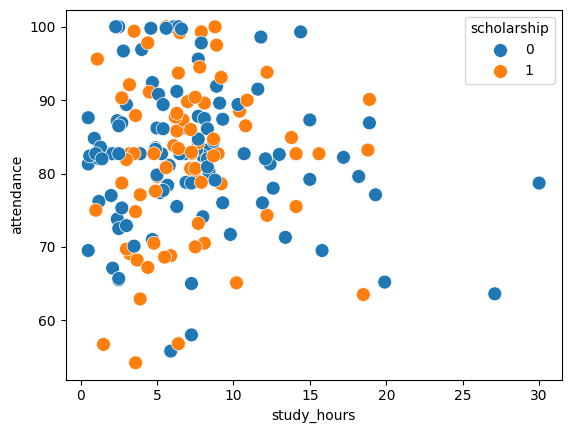

In [30]:
sns.scatterplot(df,x=df['study_hours'],y=df['attendance'],hue=df['scholarship'],linewidth=0.5,s=100)

In [31]:
model1.coef_

array([[ 0.00571678, -0.01186055]])

In [32]:
model1.intercept_

array([0.73540754])

<Axes: xlabel='study_hours', ylabel='attendance'>

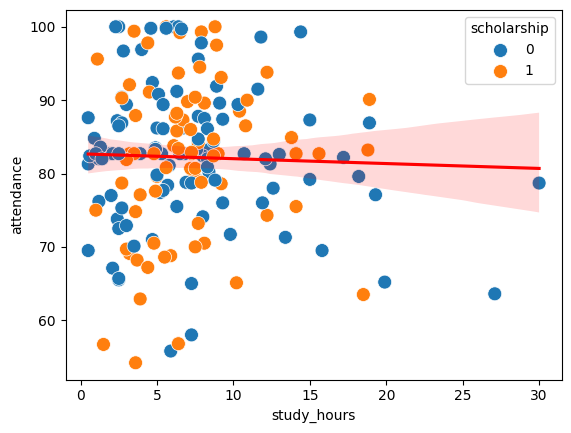

In [33]:
sns.scatterplot(df,x=df['study_hours'],y=df['attendance'],hue=df['scholarship'],linewidth=0.5,s=100)
sns.regplot(df,x=df['study_hours'],y=df['attendance'],scatter=False,color='red')

### confusion matrix for the train data

In [34]:
cm=confusion_matrix(Y_train,prediction_on_traning)

In [35]:
cm


array([[77,  4],
       [61,  5]])

Text(50.722222222222214, 0.5, 'Actual testing data')

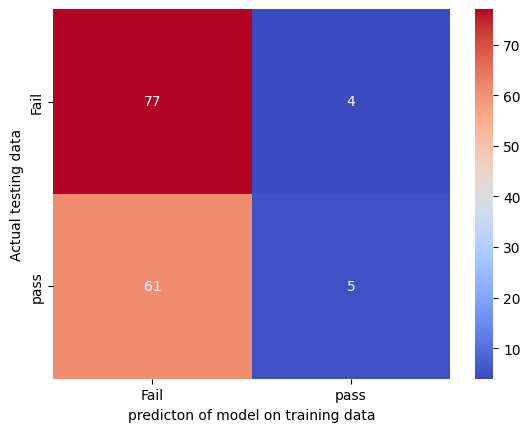

In [ ]:
sns.heatmap(cm,annot=True,cmap='coolwarm',xticklabels=(['Fail','pass']),yticklabels=(['Fail','pass']),fmt='d')
plt.xlabel("predicton of model on training data")
plt.ylabel("Actual training data")

### confusion matrix on testing data

In [49]:
cm=confusion_matrix(Y_test,prediction_on_testing)
cm

array([[23,  2],
       [10,  2]])

Text(50.722222222222214, 0.5, 'Actual testing data')

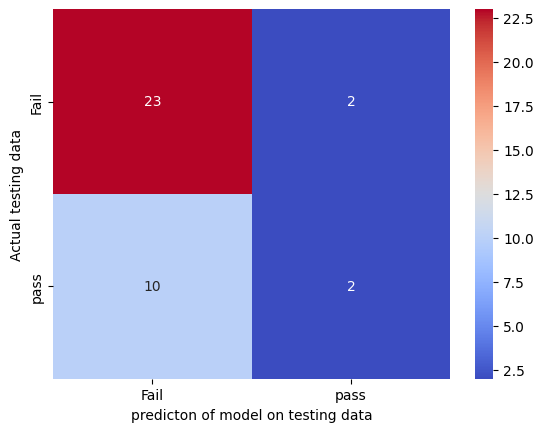

In [50]:
sns.heatmap(cm,annot=True,cmap='coolwarm',xticklabels=(['Fail','pass']),yticklabels=(['Fail','pass']),fmt='d')
plt.xlabel("predicton of model on testing data")
plt.ylabel("Actual testing data")